# Import libraries

In [34]:
import os
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)  
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph

## 1.1 Create the energy system

In [35]:
from oemof.solph import NonConvex

# read the input data file
filename = r"OEMOF_files/Step4.csv"
data = pd.read_csv(filename, delimiter=";")


# specifying the solver
solver = "gurobi"
solver_verbose = False

# Create energy system
datetimeindex = create_time_index(2022, number=len(data)) # By default, the function creates an hourly index for one year.
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system
# Buses
electrical_bus_grid = Bus(label="electrical_bus") # Electricity bus
thermal_bus = Bus(label="thermal_bus") # Heat bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biogas_bus = Bus(label="biogas_bus") # Natural gas bus
electrical_bus_CHP = Bus(label="electricity_chp_bus") # Electricity bus CHP

energysystem.add(electrical_bus_grid, thermal_bus, gas_bus, biogas_bus, electrical_bus_CHP)




# Excess electricity sink
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus_CHP: Flow(variable_costs=data["electricity_price"] * -1)}
    )
)

# Gas source with cost from gas + CO2
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow(variable_costs=data["gas_price"] + data["co2_price"] * 0.2008)})
                )



# Gas source with cost biogas
energysystem.add(
    Source(label="bio_gas",outputs={biogas_bus: Flow(variable_costs=60.0)})
                )

# Grid electricity source with cost electricity + CO2
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus_grid: Flow(variable_costs=data["electricity_price"] + data["co2_price"] * 0.026)})
                )

# Thermal demand sink
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value= 4.05352482103703,

            fix=data["thermal_demand"]  #/max(data["thermal_demand"])
        )},
    )
)


# natural gas CHP (0.85MW)
energysystem.add(
    Converter(
        label="chp_gas",
        inputs={gas_bus: Flow()},
        outputs={
            electrical_bus_CHP: Flow(),
            thermal_bus: Flow(nominal_value=0.85,
                              min=0.1,
                              variable_costs=0.29)
        },
        conversion_factors={electrical_bus_CHP: 0.36, thermal_bus: 0.54}
    )
)

# biomass CHP (0.6MW)
energysystem.add(
    Converter(
        label="chp_bio",
        inputs={biogas_bus: Flow()}, 
        outputs={
            electrical_bus_CHP: Flow(                              
                                 ),
            thermal_bus: Flow(nominal_value=0.6, 
                              min=0.1,
                              variable_costs=2.5)
        },
        conversion_factors={electrical_bus_CHP: 0.40, thermal_bus: 0.42}
    )
)


# Electric boiler (1.1MW)
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={electrical_bus_grid: Flow()},
        outputs={thermal_bus: Flow(nominal_value=1.1, variable_costs=0.5)},
        conversion_factors={thermal_bus: 0.99} 
    )
)


# Heat Pump 0.79 MW
energysystem.add(
    Converter(
        label="heat_pump_0.79_MW",
        inputs={electrical_bus_grid: Flow()},
        outputs={thermal_bus: Flow(nominal_value=0.79, variable_costs=1.5)},
        conversion_factors={thermal_bus: 3.5} 
    )
)

# Heat Pump 0.94 MW
energysystem.add(
    Converter(
        label="heat_pump_0.94_MW",
        inputs={electrical_bus_grid: Flow()},
        outputs={thermal_bus: Flow(nominal_value=0.94, variable_costs=1.7)},
        conversion_factors={thermal_bus: 3.5} 
    )
)




Only CO2 price

## 1.2 Build and solve model

In [ ]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='gurobi',
    solve_kwargs={"tee": solver_verbose},
    options={"mip_gap": 0.002}   # 2% relative MIP gap
)


# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")

energysystem.dump(os.getcwd(), "Outputs/results.oemof")

logging.info("Results have been dumped.")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

In [ ]:
energysystem.results

results = energysystem.results["main"]

# get all variables of a specific component/bus
thermal_bus = views.node(results, "thermal_bus")


### Analyse thermal node

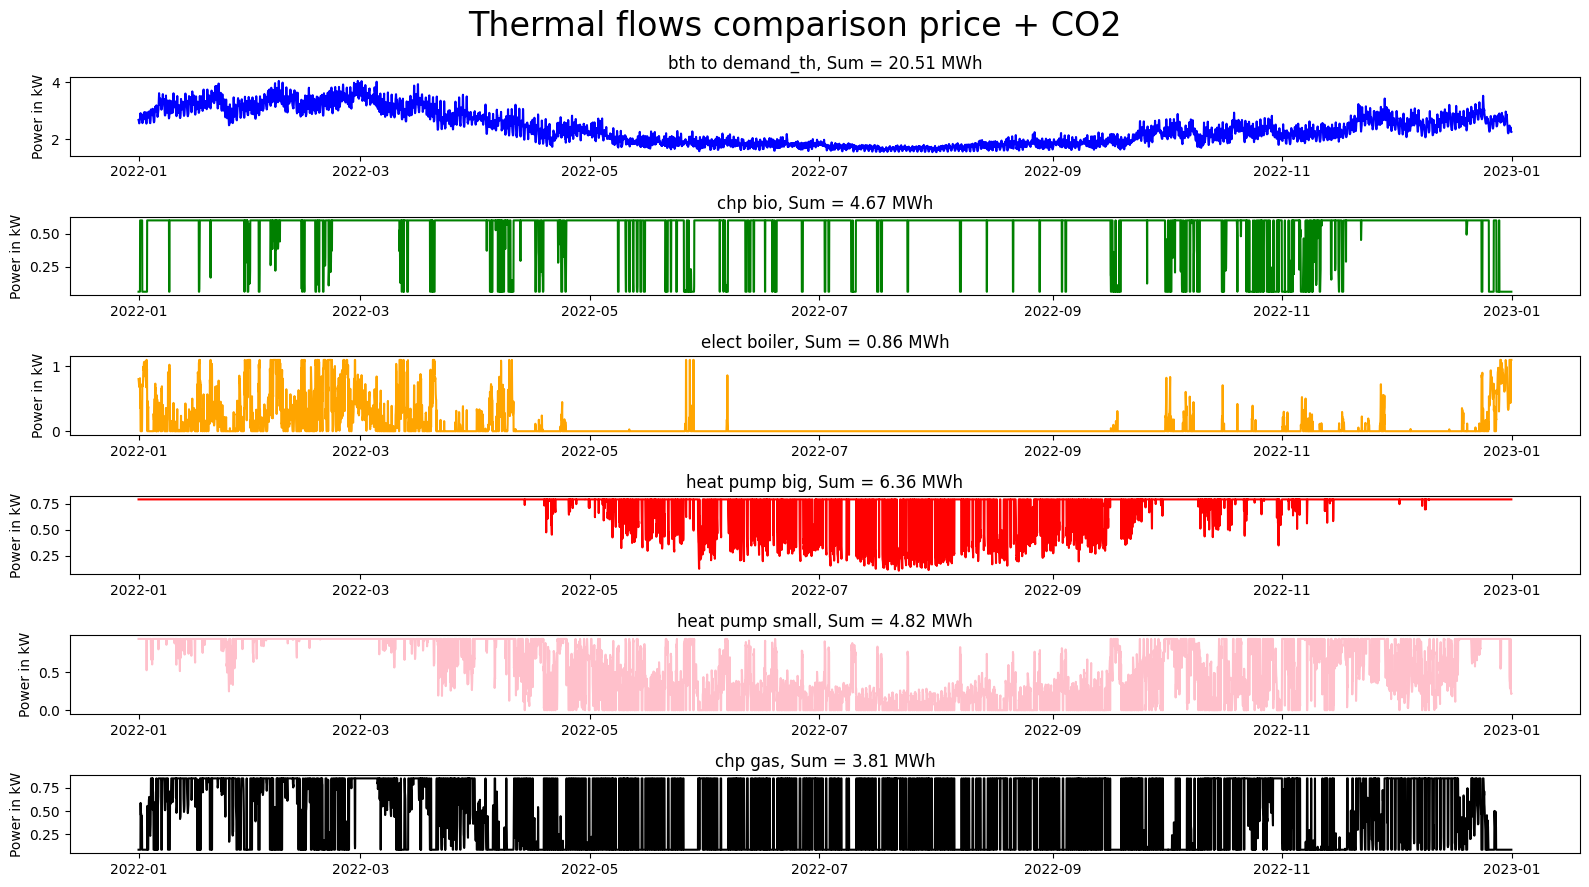

In [39]:
Sum_th_demand = thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp_gas = thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_chp_bio = thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_big = thermal_bus["sequences"][(('heat_pump_0.79_MW', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp_small = thermal_bus["sequences"][(('heat_pump_0.94_MW', 'thermal_bus'), 'flow')].sum()

fig, axs = plt.subplots(6,figsize=(16, 9))
fig.suptitle('Thermal flows comparison price + CO2', fontsize=24)
axs[0].plot(thermal_bus["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'bth to demand_th, Sum = {round(float(Sum_th_demand/1000), 2)} MWh')
axs[1].plot(thermal_bus["sequences"][(('chp_bio', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'chp bio, Sum = {round(float(Sum_th_prod_chp_bio/1000),2)} MWh')
axs[2].plot(thermal_bus["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'elect boiler, Sum = {round(float(Sum_th_prod_boiler/1000),2)} MWh')
axs[3].plot(thermal_bus["sequences"][(('heat_pump_0.79_MW', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'heat pump big, Sum = {round(float(Sum_th_prod_hp_big/1000),2)} MWh')
axs[4].plot(thermal_bus["sequences"][(('heat_pump_0.94_MW', 'thermal_bus'), 'flow')], 'pink')
axs[4].set_title(f'heat pump small, Sum = {round(float(Sum_th_prod_hp_small/1000),2)} MWh')
axs[5].plot(thermal_bus["sequences"][(('chp_gas', 'thermal_bus'), 'flow')], 'black')
axs[5].set_title(f'chp gas, Sum = {round(float(Sum_th_prod_chp_gas/1000),2)} MWh')

axs[0].set_ylabel('Power in kW')
axs[1].set_ylabel('Power in kW')
axs[2].set_ylabel('Power in kW')
axs[3].set_ylabel('Power in kW')
axs[4].set_ylabel('Power in kW')
axs[5].set_ylabel('Power in kW')


plt.tight_layout()
plt.show()

In [40]:
print("Total system cost [k€ ]:", model.objective()/1000)

Total system cost [k€ ]: 541.8326495855408
